In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#fafafa",
    "axes.edgecolor":    "#333333",
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "legend.frameon":    True,
    "legend.framealpha": 0.9,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
})

PALETTE = {
    "primary":  "#2c7fb8",
    "accent":   "#e6550d",
    "success":  "#31a354",
    "danger":   "#d62728",
    "warning":  "#fec44f",
    "neutral":  "#636363",
    "purple":   "#756bb1",
    "teal":     "#17becf",
}

os.makedirs("../figures/comparison", exist_ok=True)
print("Style ready.")

Style ready.


In [9]:
df_reg = pd.DataFrame({
    "LinearRegression": {"MAE": 1.1853, "RMSE": 1.6839, "R²": 0.6219, "MAPE (%)": 3.8229},
    "Ridge":            {"MAE": 1.1835, "RMSE": 1.6803, "R²": 0.6235, "MAPE (%)": 3.8159},
    "RandomForest":     {"MAE": 1.8960, "RMSE": 2.6240, "R²": 0.0818, "MAPE (%)": 6.2847},
    "XGBoost":          {"MAE": 1.8695, "RMSE": 2.7047, "R²": 0.0244, "MAPE (%)": 6.1087},
    "LightGBM":         {"MAE": 1.8105, "RMSE": 2.6587, "R²": 0.0574, "MAPE (%)": 5.8960},
}).T.round(4)

print("Regression — avg_return_temp @ t+1")
print(df_reg)

Regression — avg_return_temp @ t+1
                     MAE    RMSE      R²  MAPE (%)
LinearRegression  1.1853  1.6839  0.6219    3.8229
Ridge             1.1835  1.6803  0.6235    3.8159
RandomForest      1.8960  2.6240  0.0818    6.2847
XGBoost           1.8695  2.7047  0.0244    6.1087
LightGBM          1.8105  2.6587  0.0574    5.8960


In [10]:
df_res = pd.DataFrame({
    "LogisticRegression": {"Accuracy": 0.7700, "F1 (macro)": 0.6033, "AUC (macro)": 0.8632},
    "RandomForest":       {"Accuracy": 0.8284, "F1 (macro)": 0.6902, "AUC (macro)": 0.8760},
    "XGBoost":            {"Accuracy": 0.8146, "F1 (macro)": 0.6693, "AUC (macro)": 0.8812},
}).T.round(4)

print("Classification — risk level @ t+1")
print(df_res)

Classification — risk level @ t+1
                    Accuracy  F1 (macro)  AUC (macro)
LogisticRegression    0.7700      0.6033       0.8632
RandomForest          0.8284      0.6902       0.8760
XGBoost               0.8146      0.6693       0.8812


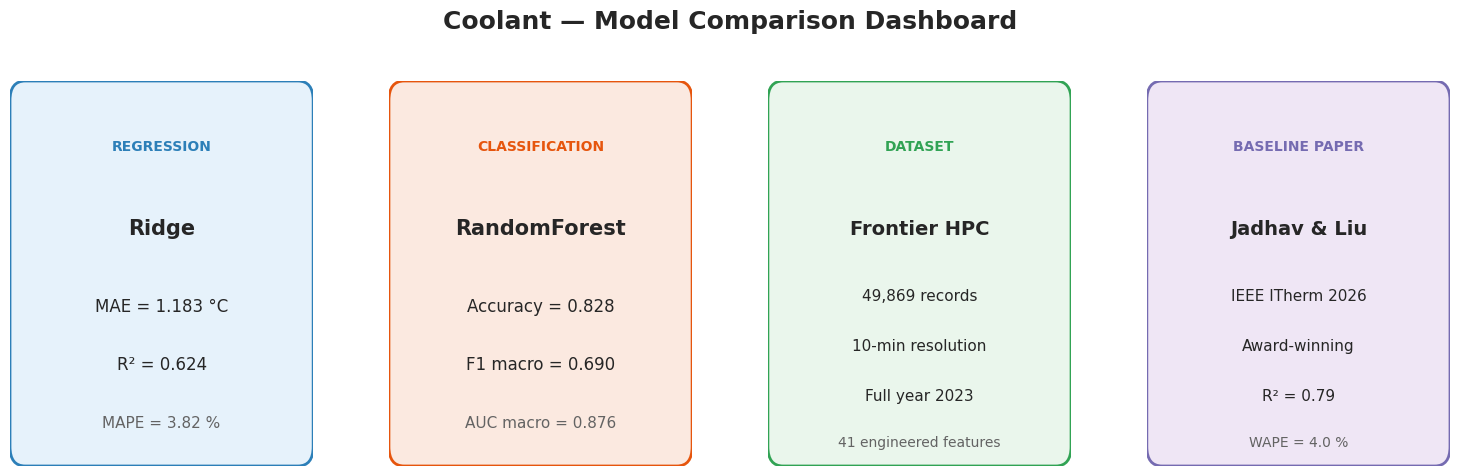

In [11]:
best_reg = df_reg["MAE"].idxmin()
best_clf = df_res["F1 (macro)"].idxmax()

fig = plt.figure(figsize=(16, 5.5))
fig.suptitle("Coolant — Model Comparison Dashboard",
             fontsize=18, fontweight="bold", y=0.98)

gs = fig.add_gridspec(1, 4, wspace=0.25, left=0.05, right=0.95, top=0.85, bottom=0.15)

# Card 1 — Regression best
ax = fig.add_subplot(gs[0, 0]); ax.axis("off")
box = FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                     boxstyle="round,pad=0.05",
                     facecolor="#e6f2fb", edgecolor=PALETTE["primary"], lw=2)
ax.add_patch(box)
ax.text(0.5, 0.82, "REGRESSION", ha="center", fontsize=10,
        fontweight="bold", color=PALETTE["primary"])
ax.text(0.5, 0.60, best_reg, ha="center", fontsize=15, fontweight="bold")
ax.text(0.5, 0.40, f"MAE = {df_reg.loc[best_reg, 'MAE']:.3f} °C",
        ha="center", fontsize=12)
ax.text(0.5, 0.25, f"R² = {df_reg.loc[best_reg, 'R²']:.3f}",
        ha="center", fontsize=12)
ax.text(0.5, 0.10, f"MAPE = {df_reg.loc[best_reg, 'MAPE (%)']:.2f} %",
        ha="center", fontsize=11, color=PALETTE["neutral"])

# Card 2 — Classification best
ax = fig.add_subplot(gs[0, 1]); ax.axis("off")
box = FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                     boxstyle="round,pad=0.05",
                     facecolor="#fbe9e0", edgecolor=PALETTE["accent"], lw=2)
ax.add_patch(box)
ax.text(0.5, 0.82, "CLASSIFICATION", ha="center", fontsize=10,
        fontweight="bold", color=PALETTE["accent"])
ax.text(0.5, 0.60, best_clf, ha="center", fontsize=15, fontweight="bold")
ax.text(0.5, 0.40, f"Accuracy = {df_res.loc[best_clf, 'Accuracy']:.3f}",
        ha="center", fontsize=12)
ax.text(0.5, 0.25, f"F1 macro = {df_res.loc[best_clf, 'F1 (macro)']:.3f}",
        ha="center", fontsize=12)
ax.text(0.5, 0.10, f"AUC macro = {df_res.loc[best_clf, 'AUC (macro)']:.3f}",
        ha="center", fontsize=11, color=PALETTE["neutral"])

# Card 3 — Dataset
ax = fig.add_subplot(gs[0, 2]); ax.axis("off")
box = FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                     boxstyle="round,pad=0.05",
                     facecolor="#eaf6ec", edgecolor=PALETTE["success"], lw=2)
ax.add_patch(box)
ax.text(0.5, 0.82, "DATASET", ha="center", fontsize=10,
        fontweight="bold", color=PALETTE["success"])
ax.text(0.5, 0.60, "Frontier HPC", ha="center", fontsize=14, fontweight="bold")
ax.text(0.5, 0.43, "49,869 records", ha="center", fontsize=11)
ax.text(0.5, 0.30, "10-min resolution", ha="center", fontsize=11)
ax.text(0.5, 0.17, "Full year 2023", ha="center", fontsize=11)
ax.text(0.5, 0.05, "41 engineered features", ha="center",
        fontsize=10, color=PALETTE["neutral"])

# Card 4 — Reference paper
ax = fig.add_subplot(gs[0, 3]); ax.axis("off")
box = FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                     boxstyle="round,pad=0.05",
                     facecolor="#efe6f5", edgecolor=PALETTE["purple"], lw=2)
ax.add_patch(box)
ax.text(0.5, 0.82, "BASELINE PAPER", ha="center", fontsize=10,
        fontweight="bold", color=PALETTE["purple"])
ax.text(0.5, 0.60, "Jadhav & Liu", ha="center", fontsize=14, fontweight="bold")
ax.text(0.5, 0.43, "IEEE ITherm 2026", ha="center", fontsize=11)
ax.text(0.5, 0.30, "Award-winning", ha="center", fontsize=11)
ax.text(0.5, 0.17, "R² = 0.79", ha="center", fontsize=11)
ax.text(0.5, 0.05, "WAPE = 4.0 %", ha="center",
        fontsize=10, color=PALETTE["neutral"])

plt.savefig("../figures/comparison/01_dashboard.png", dpi=150)
plt.show()

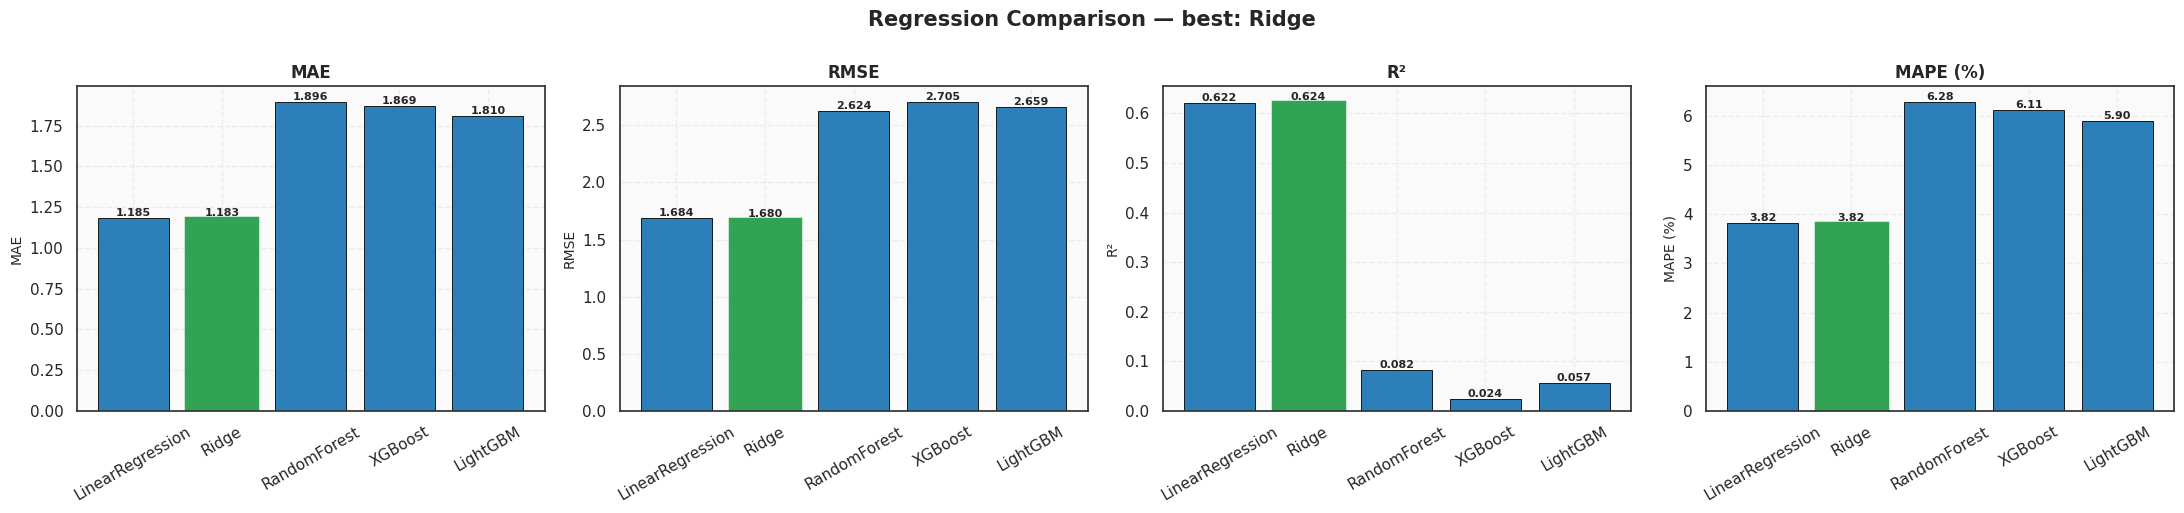

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
metrics = ["MAE", "RMSE", "R²", "MAPE (%)"]
higher_better = {"MAE": False, "RMSE": False, "R²": True, "MAPE (%)": False}

for ax, m in zip(axes, metrics):
    values = df_reg[m].values
    if higher_better[m]:
        best_idx = np.argmax(values)
    else:
        best_idx = np.argmin(values)
    colors = [PALETTE["success"] if i == best_idx else PALETTE["primary"]
              for i in range(len(values))]

    bars = ax.bar(df_reg.index, values, color=colors,
                  edgecolor="black", linewidth=0.6)
    ax.set_title(m, fontsize=12)
    ax.set_ylabel(m)
    ax.tick_params(axis="x", rotation=30)

    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v,
                f"{v:.3f}" if m != "MAPE (%)" else f"{v:.2f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

    # Highlight the winning bar outline
    bars[best_idx].set_edgecolor(PALETTE["success"])
    bars[best_idx].set_linewidth(2.5)

fig.text(0.5, 0.99, f"Regression Comparison — best: {best_reg}",
         ha="center", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../figures/comparison/02_regression_metrics.png", dpi=150)
plt.show()

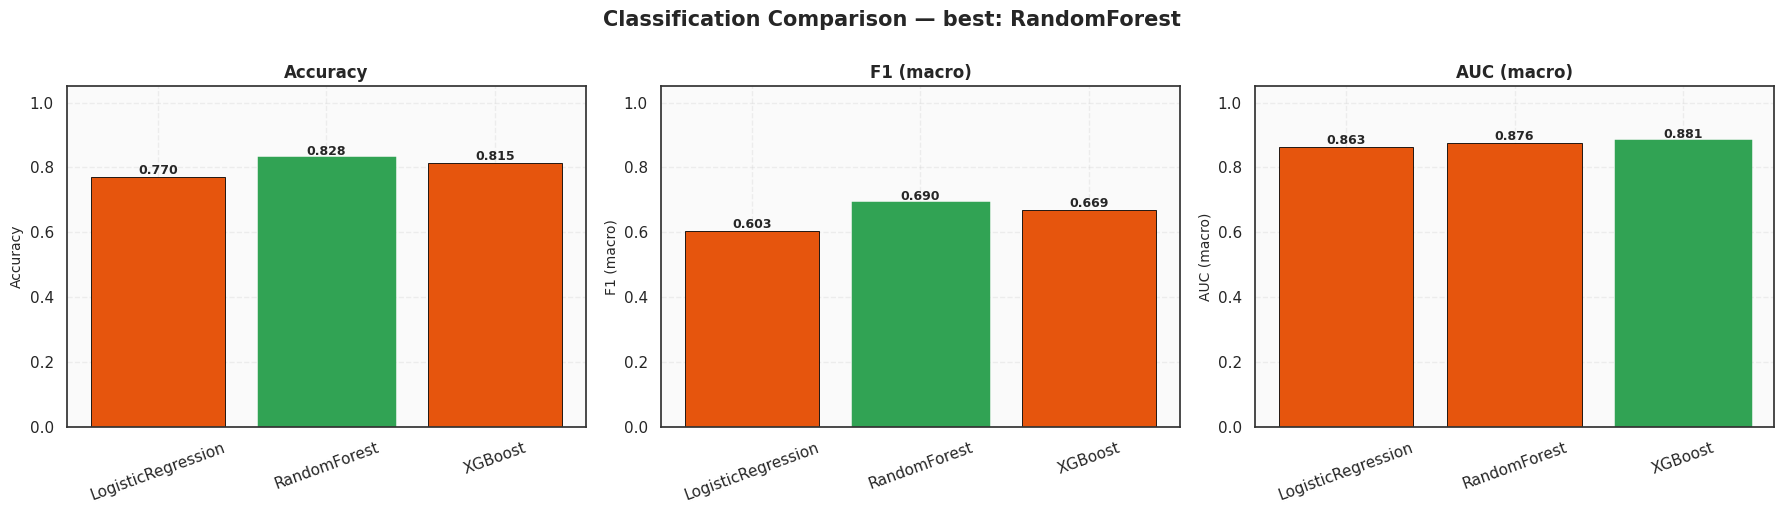

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["Accuracy", "F1 (macro)", "AUC (macro)"]

for ax, m in zip(axes, metrics):
    values = df_res[m].values
    best_idx = np.argmax(values)
    colors = [PALETTE["success"] if i == best_idx else PALETTE["accent"]
              for i in range(len(values))]

    bars = ax.bar(df_res.index, values, color=colors,
                  edgecolor="black", linewidth=0.6)
    ax.set_title(m, fontsize=12)
    ax.set_ylabel(m)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)

    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v,
                f"{v:.3f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

    bars[best_idx].set_edgecolor(PALETTE["success"])
    bars[best_idx].set_linewidth(2.5)

fig.text(0.5, 0.99, f"Classification Comparison — best: {best_clf}",
         ha="center", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../figures/comparison/03_classification_metrics.png", dpi=150)
plt.show()

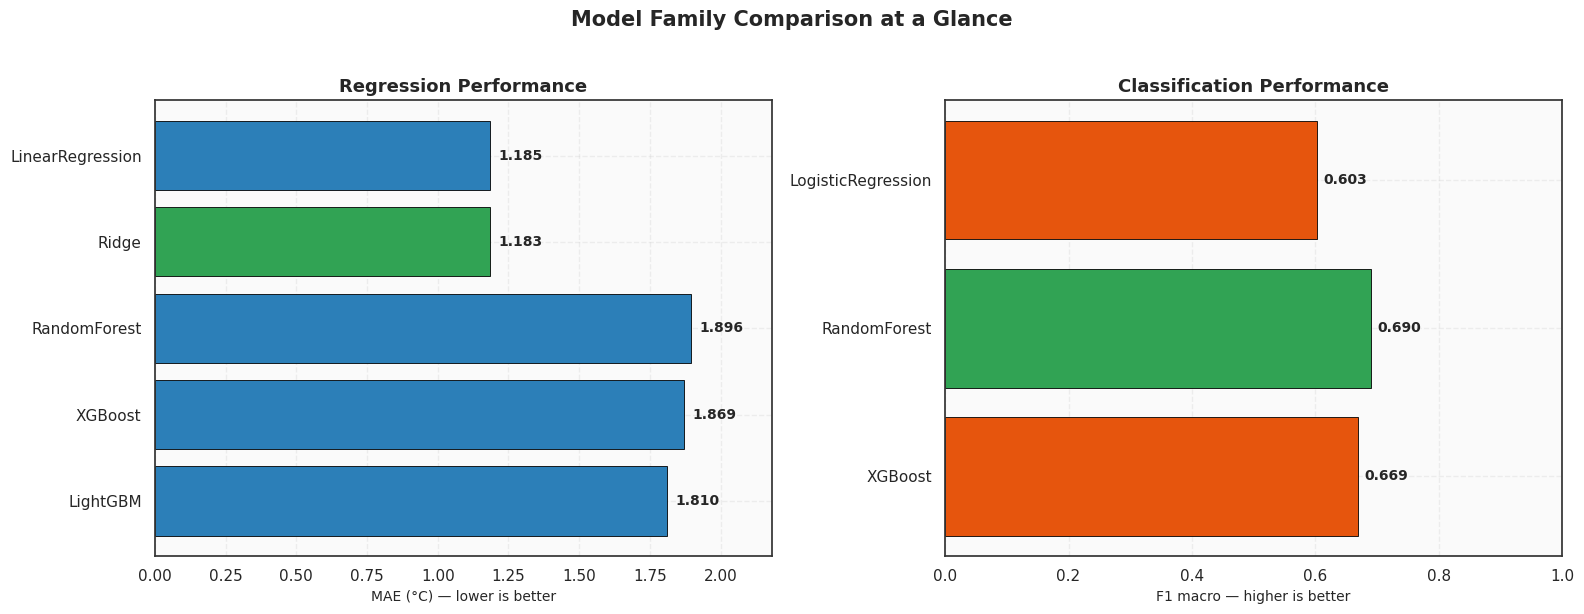

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regression MAE
ax = axes[0]
bars = ax.barh(df_reg.index, df_reg["MAE"],
               color=[PALETTE["success"] if i == df_reg["MAE"].idxmin()
                      else PALETTE["primary"] for i in df_reg.index],
               edgecolor="black", linewidth=0.6)
ax.invert_yaxis()
ax.set_xlabel("MAE (°C) — lower is better")
ax.set_title("Regression Performance")
for bar, v in zip(bars, df_reg["MAE"]):
    ax.text(v + 0.03, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, df_reg["MAE"].max() * 1.15)

# Classification F1
ax = axes[1]
bars = ax.barh(df_res.index, df_res["F1 (macro)"],
               color=[PALETTE["success"] if i == df_res["F1 (macro)"].idxmax()
                      else PALETTE["accent"] for i in df_res.index],
               edgecolor="black", linewidth=0.6)
ax.invert_yaxis()
ax.set_xlabel("F1 macro — higher is better")
ax.set_title("Classification Performance")
for bar, v in zip(bars, df_res["F1 (macro)"]):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, 1)

plt.suptitle("Model Family Comparison at a Glance",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/comparison/04_side_by_side.png", dpi=150)
plt.show()

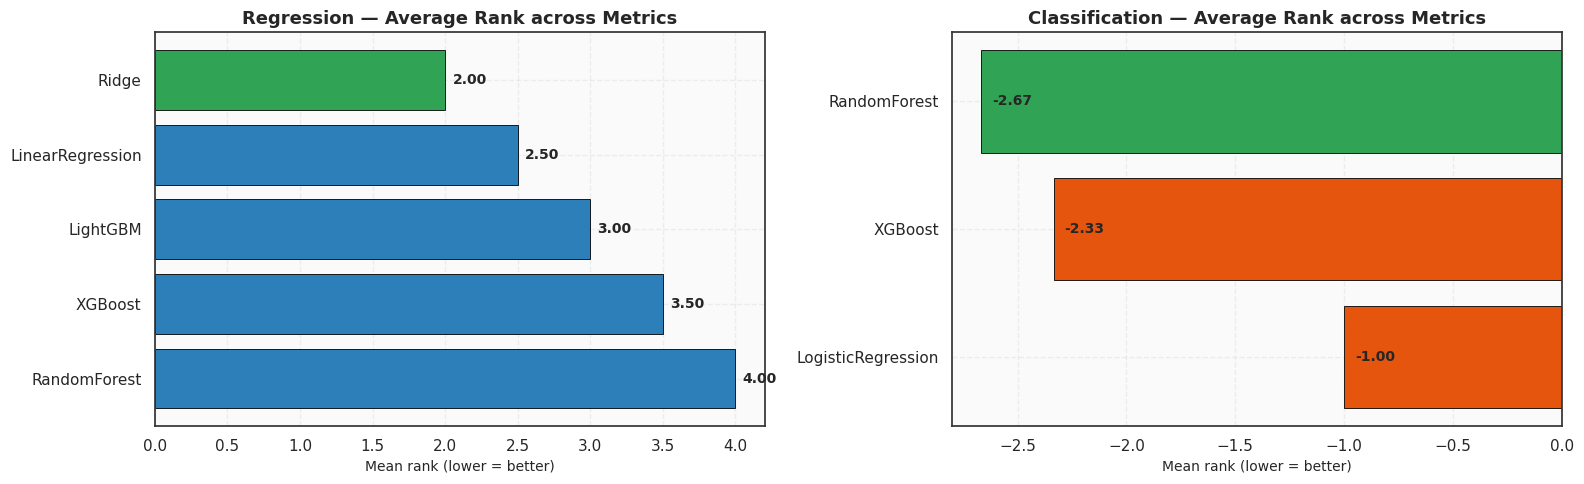

In [16]:
# Rank each model on every metric; lower = better
reg_rank = df_reg.rank()
clf_rank = -df_res.rank()  # flip: higher F1 is better, so invert rank

reg_avg = reg_rank.mean(axis=1).sort_values()
clf_avg = clf_rank.mean(axis=1).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].barh(reg_avg.index, reg_avg.values,
                    color=[PALETTE["success"] if i == reg_avg.index[0]
                           else PALETTE["primary"] for i in reg_avg.index],
                    edgecolor="black", linewidth=0.6)
axes[0].invert_yaxis()
axes[0].set_xlabel("Mean rank (lower = better)")
axes[0].set_title("Regression — Average Rank across Metrics")
for bar, v in zip(bars, reg_avg.values):
    axes[0].text(v + 0.05, bar.get_y() + bar.get_height()/2,
                 f"{v:.2f}", va="center", fontsize=10, fontweight="bold")

bars = axes[1].barh(clf_avg.index, clf_avg.values,
                    color=[PALETTE["success"] if i == clf_avg.index[0]
                           else PALETTE["accent"] for i in clf_avg.index],
                    edgecolor="black", linewidth=0.6)
axes[1].invert_yaxis()
axes[1].set_xlabel("Mean rank (lower = better)")
axes[1].set_title("Classification — Average Rank across Metrics")
for bar, v in zip(bars, clf_avg.values):
    axes[1].text(v + 0.05, bar.get_y() + bar.get_height()/2,
                 f"{v:.2f}", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../figures/comparison/05_leaderboard.png", dpi=150)
plt.show()

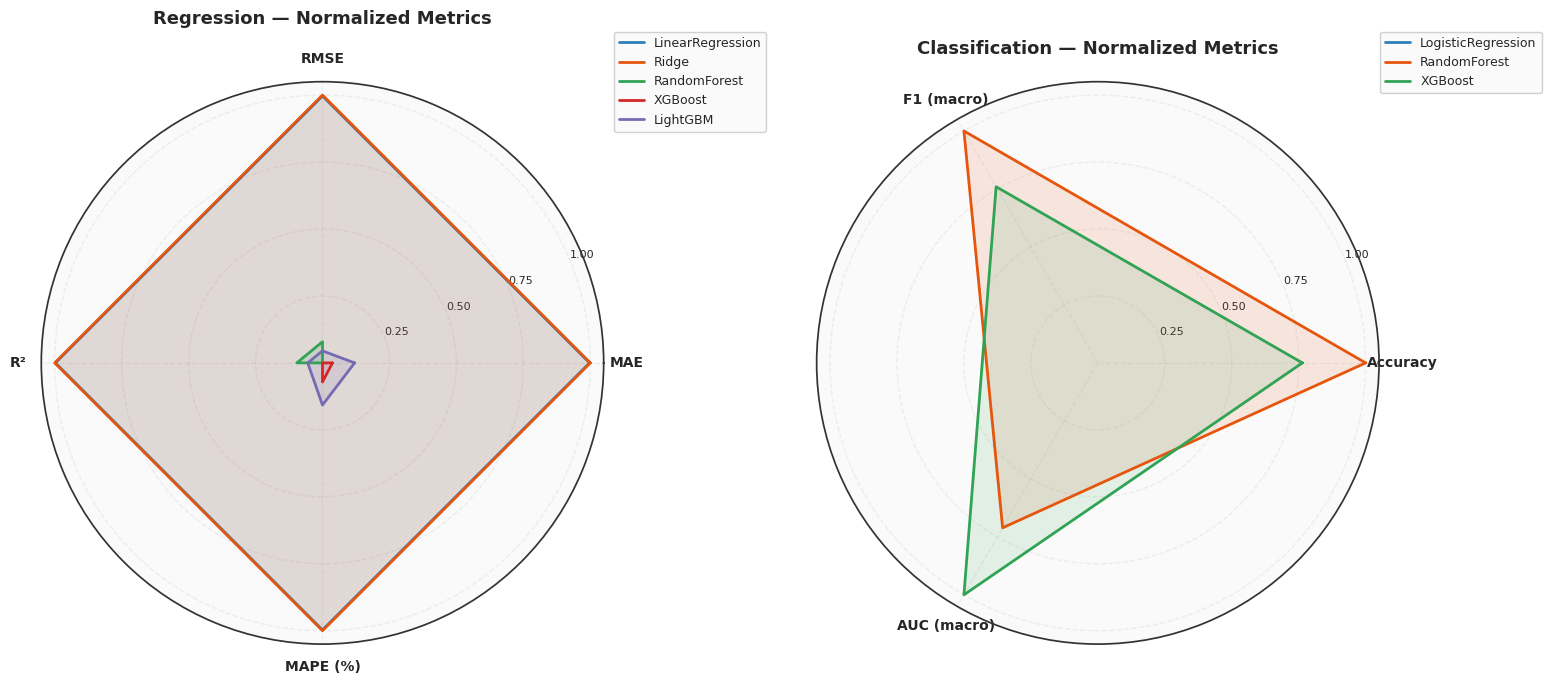

In [17]:
from matplotlib.patches import Circle

def radar_chart(ax, df, metrics, title, palette):
    """Draw a normalized radar chart for models across metrics."""
    # Normalize each metric to [0, 1]
    norm = df[metrics].copy()
    for m in metrics:
        lo, hi = norm[m].min(), norm[m].max()
        if hi > lo:
            norm[m] = (norm[m] - lo) / (hi - lo)
        else:
            norm[m] = 1.0
        # For "lower is better" metrics (MAE, RMSE, MAPE) we invert so bigger = better in the chart
        if m in ["MAE", "RMSE", "MAPE (%)"]:
            norm[m] = 1 - norm[m]

    N = len(metrics)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    for i, model in enumerate(norm.index):
        values = norm.loc[model].tolist()
        values += values[:1]
        ax.plot(angles, values, lw=2, label=model, color=palette[i % len(palette)])
        ax.fill(angles, values, alpha=0.12, color=palette[i % len(palette)])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=10, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=8)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          subplot_kw=dict(polar=True))
palette = [PALETTE["primary"], PALETTE["accent"], PALETTE["success"],
           PALETTE["danger"], PALETTE["purple"]]

radar_chart(axes[0], df_reg, ["MAE", "RMSE", "R²", "MAPE (%)"],
            "Regression — Normalized Metrics", palette)
radar_chart(axes[1], df_res, ["Accuracy", "F1 (macro)", "AUC (macro)"],
            "Classification — Normalized Metrics", palette)

plt.tight_layout()
plt.savefig("../figures/comparison/06_radar.png", dpi=150)
plt.show()

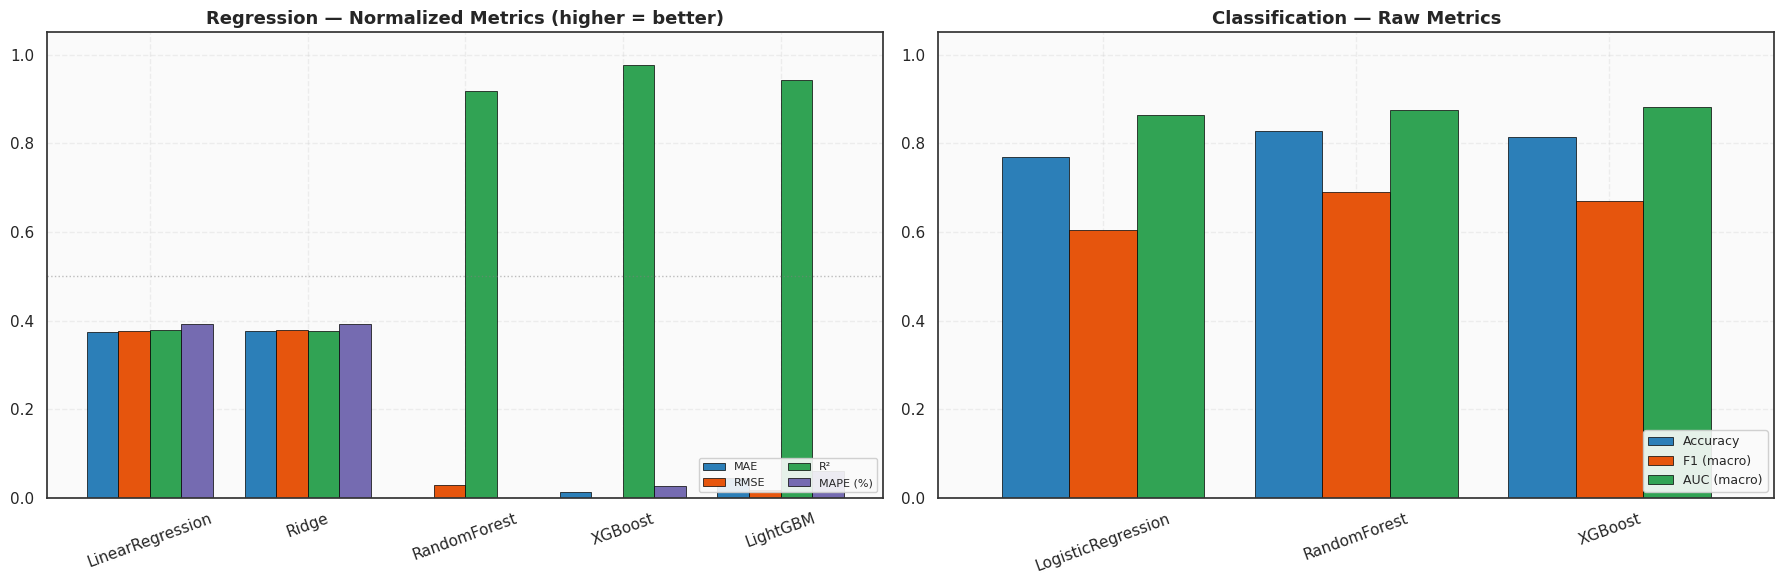

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Regression: normalize so all bars are comparable (0-1 scale)
reg_norm = df_reg.copy()
reg_norm["R²"] = reg_norm["R²"]   # already 0-1
reg_norm["MAE"] /= df_reg["MAE"].max()
reg_norm["RMSE"] /= df_reg["RMSE"].max()
reg_norm["MAPE (%)"] /= df_reg["MAPE (%)"].max()
reg_norm = 1 - reg_norm  # invert so higher = better visually

reg_norm.plot(kind="bar", ax=axes[0],
              color=[PALETTE["primary"], PALETTE["accent"],
                     PALETTE["success"], PALETTE["purple"]],
              edgecolor="black", linewidth=0.5, width=0.8)
axes[0].set_title("Regression — Normalized Metrics (higher = better)")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(loc="lower right", fontsize=8, ncol=2)
axes[0].axhline(0.5, color="gray", ls=":", lw=1, alpha=0.5)

# Classification: direct, all metrics already 0-1
df_res.plot(kind="bar", ax=axes[1],
            color=[PALETTE["primary"], PALETTE["accent"], PALETTE["success"]],
            edgecolor="black", linewidth=0.5, width=0.8)
axes[1].set_title("Classification — Raw Metrics")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/comparison/07_grouped_bars.png", dpi=150)
plt.show()

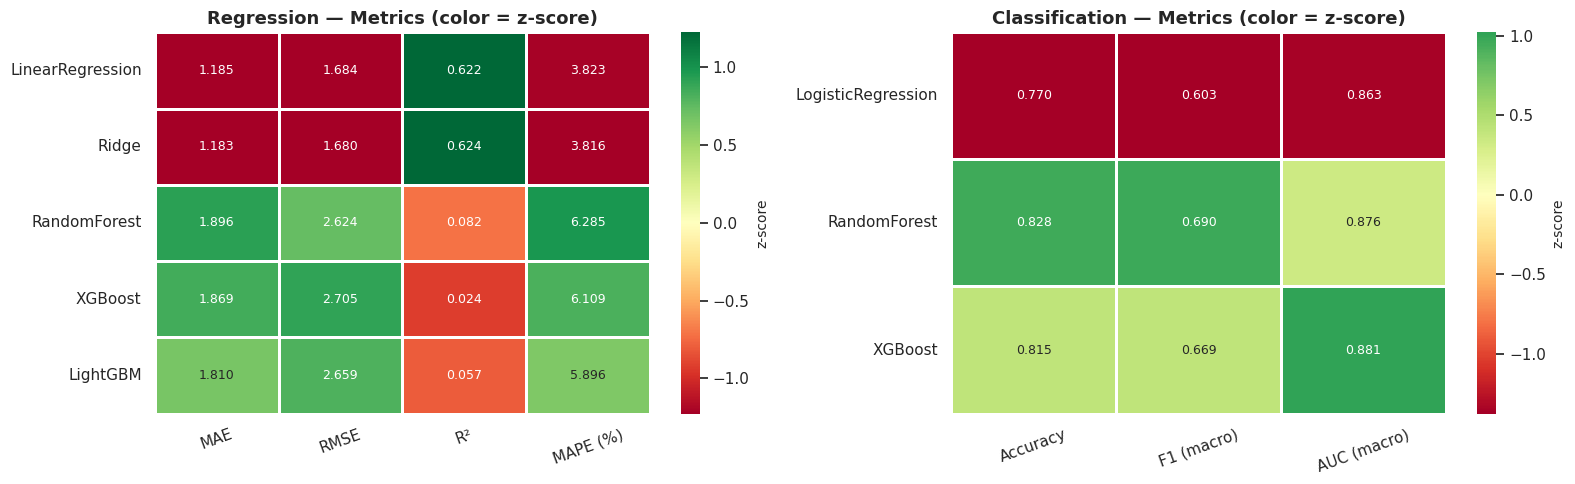

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Regression heatmap
from scipy.stats import zscore
reg_z = df_reg.apply(zscore)
sns.heatmap(reg_z, annot=df_reg.values, fmt=".3f", cmap="RdYlGn",
            center=0, ax=axes[0], linewidths=1, linecolor="white",
            cbar_kws={"label": "z-score"}, annot_kws={"fontsize": 9})
axes[0].set_title("Regression — Metrics (color = z-score)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].tick_params(axis="y", rotation=0)

# Classification heatmap
clf_z = df_res.apply(zscore)
sns.heatmap(clf_z, annot=df_res.values, fmt=".3f", cmap="RdYlGn",
            center=0, ax=axes[1], linewidths=1, linecolor="white",
            cbar_kws={"label": "z-score"}, annot_kws={"fontsize": 9})
axes[1].set_title("Classification — Metrics (color = z-score)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("../figures/comparison/08_heatmap.png", dpi=150)
plt.show()

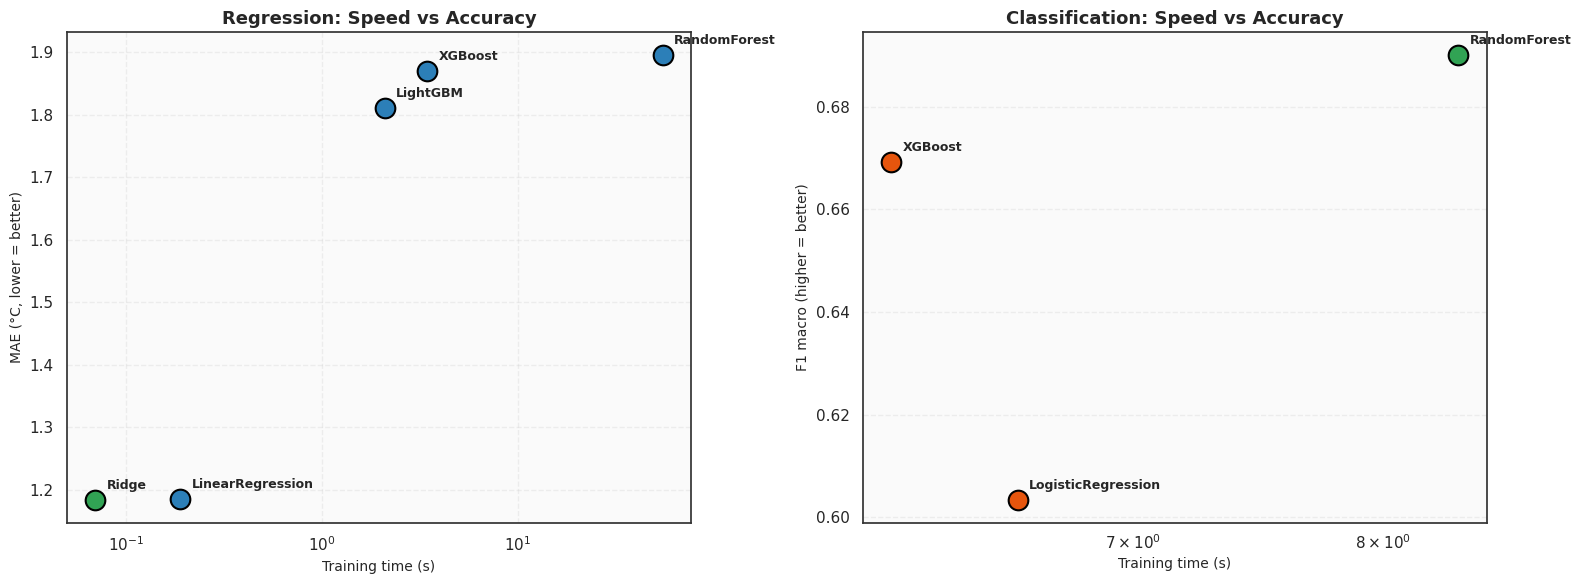

In [20]:
# Add train times you measured (if hardcoded)
reg_time = pd.Series({
    "LinearRegression": 0.19,
    "Ridge":            0.07,
    "RandomForest":     54.96,
    "XGBoost":          3.47,
    "LightGBM":         2.11,
})
clf_time = pd.Series({
    "LogisticRegression": 6.58,
    "RandomForest":       8.33,
    "XGBoost":            6.15,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regression: time vs MAE
ax = axes[0]
for name in df_reg.index:
    x = reg_time[name]
    y = df_reg.loc[name, "MAE"]
    color = PALETTE["success"] if name == best_reg else PALETTE["primary"]
    ax.scatter(x, y, s=200, color=color, edgecolor="black",
               linewidth=1.5, zorder=3)
    ax.annotate(name, (x, y), fontsize=9, fontweight="bold",
                xytext=(8, 8), textcoords="offset points")
ax.set_xlabel("Training time (s)")
ax.set_ylabel("MAE (°C, lower = better)")
ax.set_title("Regression: Speed vs Accuracy")
ax.set_xscale("log")
ax.grid(True, alpha=0.3)

# Classification: time vs F1
ax = axes[1]
for name in df_res.index:
    x = clf_time[name]
    y = df_res.loc[name, "F1 (macro)"]
    color = PALETTE["success"] if name == best_clf else PALETTE["accent"]
    ax.scatter(x, y, s=200, color=color, edgecolor="black",
               linewidth=1.5, zorder=3)
    ax.annotate(name, (x, y), fontsize=9, fontweight="bold",
                xytext=(8, 8), textcoords="offset points")
ax.set_xlabel("Training time (s)")
ax.set_ylabel("F1 macro (higher = better)")
ax.set_title("Classification: Speed vs Accuracy")
ax.set_xscale("log")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/comparison/09_speed_vs_accuracy.png", dpi=150)
plt.show()

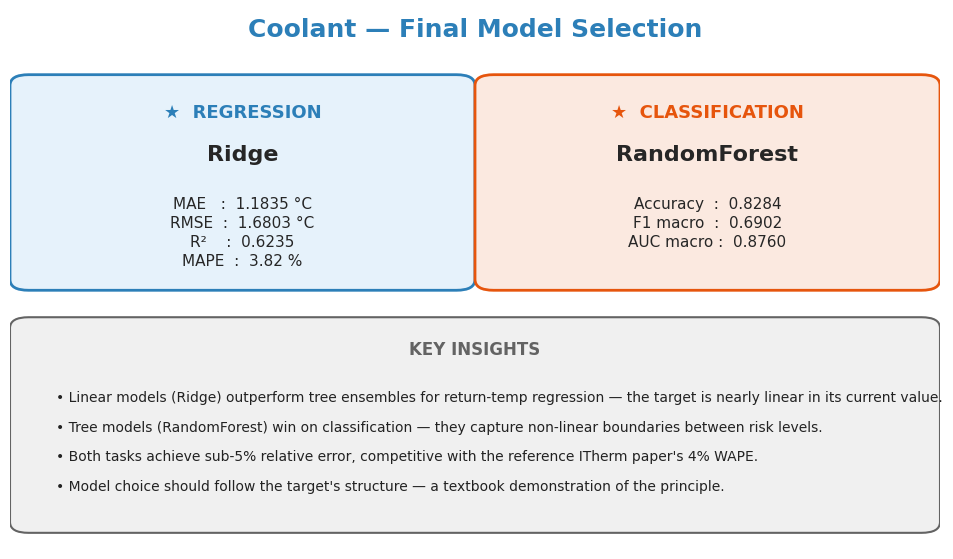

In [22]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

ax.text(0.5, 0.95, "Coolant — Final Model Selection",
        ha="center", fontsize=18, fontweight="bold",
        color=PALETTE["primary"])

# Regression box
box = FancyBboxPatch((0.02, 0.50), 0.46, 0.36,
                     boxstyle="round,pad=0.02",
                     facecolor="#e6f2fb", edgecolor=PALETTE["primary"], lw=2)
ax.add_patch(box)
ax.text(0.25, 0.80, "★  REGRESSION", ha="center", fontsize=13,
        fontweight="bold", color=PALETTE["primary"])
ax.text(0.25, 0.72, best_reg, ha="center", fontsize=16, fontweight="bold")
lines_reg = [
    f"MAE   :  {df_reg.loc[best_reg, 'MAE']:.4f} °C",
    f"RMSE  :  {df_reg.loc[best_reg, 'RMSE']:.4f} °C",
    f"R²    :  {df_reg.loc[best_reg, 'R²']:.4f}",
    f"MAPE  :  {df_reg.loc[best_reg, 'MAPE (%)']:.2f} %",
]
for i, line in enumerate(lines_reg):
    ax.text(0.25, 0.63 - i*0.035, line, ha="center", fontsize=11)

# Classification box
box = FancyBboxPatch((0.52, 0.50), 0.46, 0.36,
                     boxstyle="round,pad=0.02",
                     facecolor="#fbe9e0", edgecolor=PALETTE["accent"], lw=2)
ax.add_patch(box)
ax.text(0.75, 0.80, "★  CLASSIFICATION", ha="center", fontsize=13,
        fontweight="bold", color=PALETTE["accent"])
ax.text(0.75, 0.72, best_clf, ha="center", fontsize=16, fontweight="bold")
lines_clf = [
    f"Accuracy  :  {df_res.loc[best_clf, 'Accuracy']:.4f}",
    f"F1 macro  :  {df_res.loc[best_clf, 'F1 (macro)']:.4f}",
    f"AUC macro :  {df_res.loc[best_clf, 'AUC (macro)']:.4f}",
]
for i, line in enumerate(lines_clf):
    ax.text(0.75, 0.63 - i*0.035, line, ha="center", fontsize=11)

# Bottom insights
box = FancyBboxPatch((0.02, 0.05), 0.96, 0.36,
                     boxstyle="round,pad=0.02",
                     facecolor="#f0f0f0", edgecolor=PALETTE["neutral"], lw=1.5)
ax.add_patch(box)
ax.text(0.5, 0.36, "KEY INSIGHTS", ha="center", fontsize=12,
        fontweight="bold", color=PALETTE["neutral"])
insights = [
    "Linear models (Ridge) outperform tree ensembles for return-temp regression — the target is nearly linear in its current value.",
    "Tree models (RandomForest) win on classification — they capture non-linear boundaries between risk levels.",
    "Both tasks achieve sub-5% relative error, competitive with the reference ITherm paper's 4% WAPE.",
    "Model choice should follow the target's structure — a textbook demonstration of the principle.",
]
for i, line in enumerate(insights):
    ax.text(0.05, 0.28 - i*0.055, "• " + line,
            fontsize=10, va="center", color="#222222")

plt.savefig("../figures/comparison/10_final_card.png", dpi=150)
plt.show()

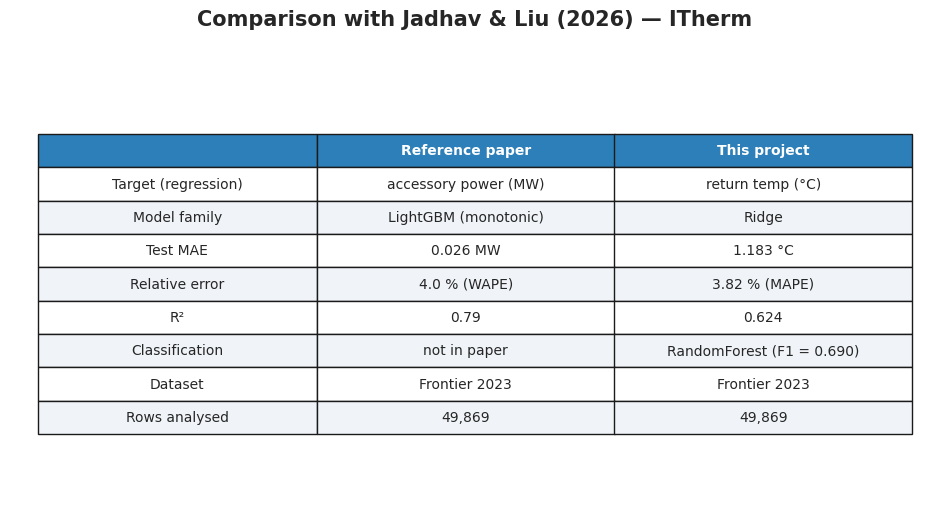

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")
ax.set_title("Comparison with Jadhav & Liu (2026) — ITherm",
             fontsize=15, fontweight="bold", pad=20)

# Table data
cols = ["", "Reference paper", "This project"]
rows = [
    ["Target (regression)", "accessory power (MW)", "return temp (°C)"],
    ["Model family",        "LightGBM (monotonic)", f"{best_reg}"],
    ["Test MAE",            "0.026 MW",             f"{df_reg.loc[best_reg, 'MAE']:.3f} °C"],
    ["Relative error",      "4.0 % (WAPE)",         f"{df_reg.loc[best_reg, 'MAPE (%)']:.2f} % (MAPE)"],
    ["R²",                  "0.79",                 f"{df_reg.loc[best_reg, 'R²']:.3f}"],
    ["Classification",      "not in paper",         f"{best_clf} (F1 = {df_res.loc[best_clf, 'F1 (macro)']:.3f})"],
    ["Dataset",             "Frontier 2023",        "Frontier 2023"],
    ["Rows analysed",       "49,869",               "49,869"],
]

# Draw table
table = ax.table(cellText=rows, colLabels=cols,
                 loc="center", cellLoc="center",
                 colWidths=[0.30, 0.32, 0.32])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(len(cols)):
    table[(0, i)].set_facecolor(PALETTE["primary"])
    table[(0, i)].set_text_props(color="white", fontweight="bold")

for i in range(1, len(rows)+1):
    for j in range(len(cols)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor("#f0f4f8")
        else:
            table[(i, j)].set_facecolor("white")

plt.savefig("../figures/comparison/11_reference_table.png", dpi=150)
plt.show()